In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


In [3]:
df = pd.read_csv('/Users/nalinguest/Desktop/Agentik Project/data/online_shoppers_intention.csv')

In [4]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:

df.dtypes




Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

### Markdown explaining why change to categorical.

In [6]:
categorical_cols = ["OperatingSystems", "Browser", "Region", "TrafficType", 
                    "Month", "VisitorType"]

df[categorical_cols] = df[categorical_cols].astype("category")


In [7]:
df.dtypes

Administrative                int64
Administrative_Duration     float64
Informational                 int64
Informational_Duration      float64
ProductRelated                int64
ProductRelated_Duration     float64
BounceRates                 float64
ExitRates                   float64
PageValues                  float64
SpecialDay                  float64
Month                      category
OperatingSystems           category
Browser                    category
Region                     category
TrafficType                category
VisitorType                category
Weekend                        bool
Revenue                        bool
dtype: object

In [ ]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(125)

In [10]:
df[df.duplicated()].head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
418,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
456,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,4,1,Returning_Visitor,False,False


### Drops all identical copies 

In [11]:
df.drop_duplicates(keep="first")

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [19]:

print("Revenue distribution (proportions):")
print(df["Revenue"].value_counts(normalize=True))

print("\nRevenue rate by Weekend:")
print(df.groupby("Weekend")["Revenue"].mean())

print("\nRevenue rate by VisitorType:")
print(df.groupby("VisitorType")["Revenue"].mean())

print("\nRevenue rate by Month:")
print(df.groupby("Month")["Revenue"].mean())

print("\nRevenue rate by Browser:")
print(df.groupby("Browser")["Revenue"].mean())

print("\nRevenue rate by Region:")
print(df.groupby("Region")["Revenue"].mean())


Revenue distribution (proportions):
Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

Revenue rate by Weekend:
Weekend
False    0.148911
True     0.173989
Name: Revenue, dtype: float64

Revenue rate by VisitorType:
VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

Revenue rate by Month:
Month
Aug     0.175520
Dec     0.125072
Feb     0.016304
Jul     0.152778
June    0.100694
Mar     0.100682
May     0.108502
Nov     0.253502
Oct     0.209472
Sep     0.191964
Name: Revenue, dtype: float64

Revenue rate by Browser:
Browser
1     0.148253
2     0.153624
3     0.047619
4     0.176630
5     0.184154
6     0.114943
7     0.122449
8     0.155556
9     0.000000
10    0.196319
11    0.166667
12    0.300000
13    0.262295
Name: Revenue, dtype: float64

Revenue rate by Region:
Region
1    0.161297
2    0.165493
3    0.145235
4    0.148054
5    0.163522
6    0.139130
7    0.156373
8    0

/var/folders/3g/39__grbn0fq4_w22vcrp4g940000gn/T/ipykernel_15588/1833223900.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("VisitorType")["Revenue"].mean())
/var/folders/3g/39__grbn0fq4_w22vcrp4g940000gn/T/ipykernel_15588/1833223900.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("Month")["Revenue"].mean())
/var/folders/3g/39__grbn0fq4_w22vcrp4g940000gn/T/ipykernel_15588/1833223900.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

Zero prevalence (counts):
Administrative    0.467802
Informational     0.786618
ProductRelated    0.003082
dtype: float64

Zero prevalence (durations):
Administrative_Duration    0.478751
Informational_Duration     0.804947
ProductRelated_Duration    0.061233
dtype: float64


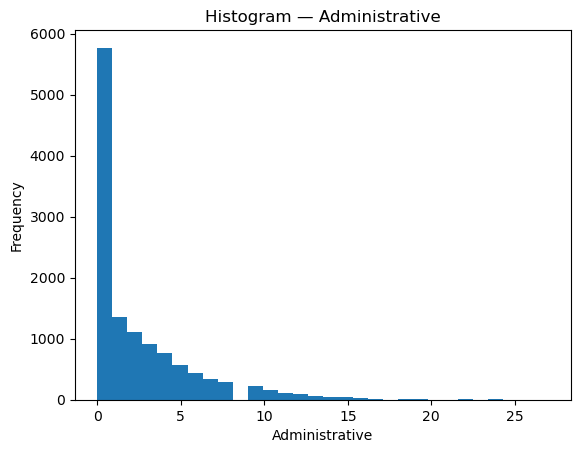

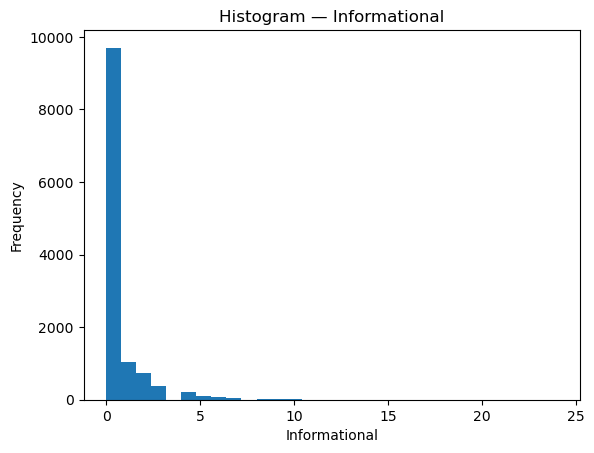

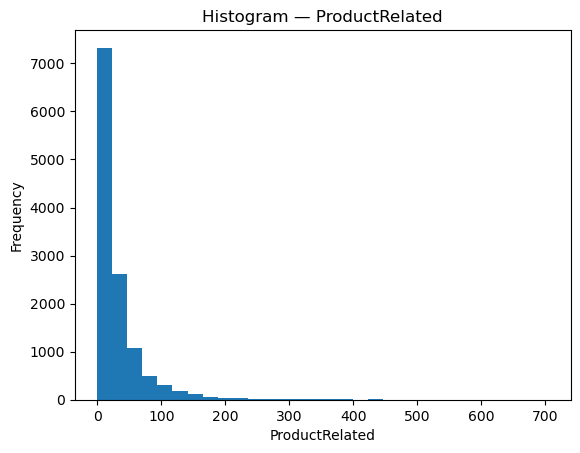

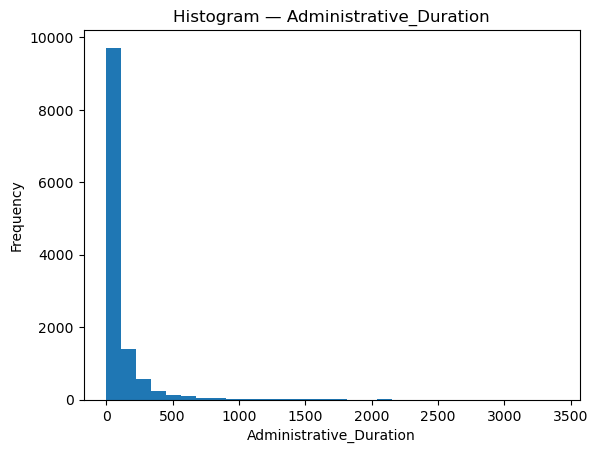

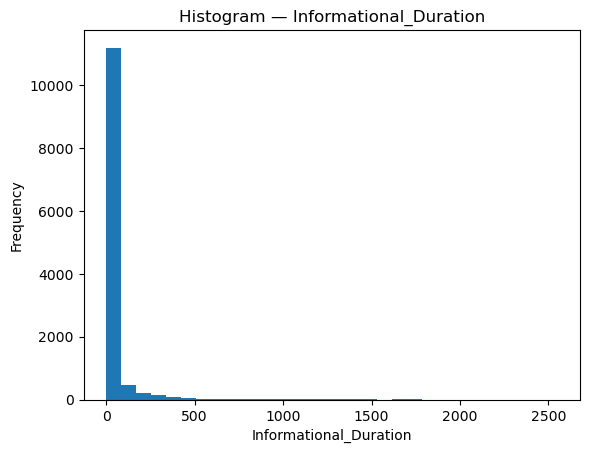

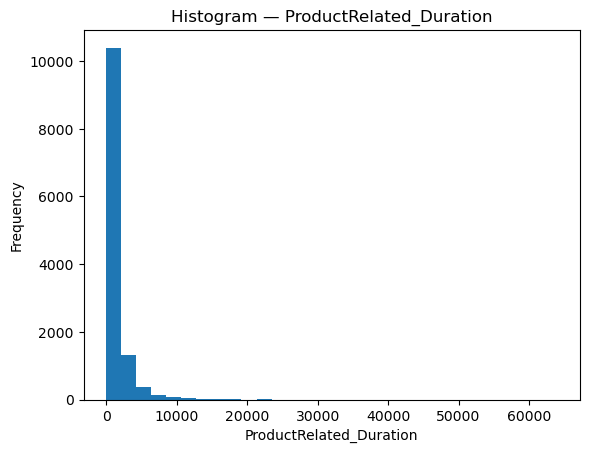

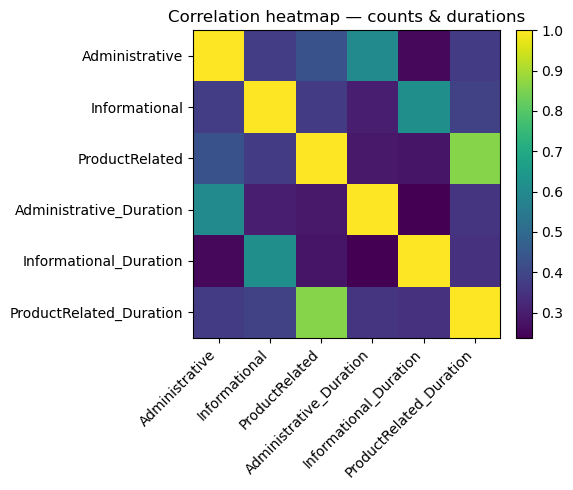

In [13]:

count_cols = ["Administrative","Informational","ProductRelated"]
dur_cols   = ["Administrative_Duration","Informational_Duration","ProductRelated_Duration"]

print("Zero prevalence (counts):")
print((df[count_cols] == 0).mean())

print("\nZero prevalence (durations):")
print((df[dur_cols] == 0).mean())

for c in count_cols:
    plt.figure()
    plt.hist(df[c].dropna(), bins=30)
    plt.title(f"Histogram — {c}")
    plt.xlabel(c); plt.ylabel("Frequency")
    plt.show()

for c in dur_cols:
    plt.figure()
    plt.hist(df[c].dropna(), bins=30)
    plt.title(f"Histogram — {c}")
    plt.xlabel(c); plt.ylabel("Frequency")
    plt.show()

behav = df[count_cols + dur_cols].copy()
corr = behav.corr()

plt.figure(figsize=(6,5))
im = plt.imshow(corr.values, interpolation='nearest')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap — counts & durations")
plt.tight_layout()
plt.show()


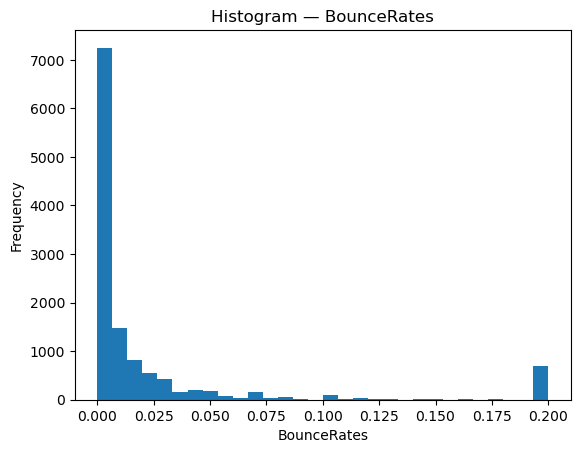

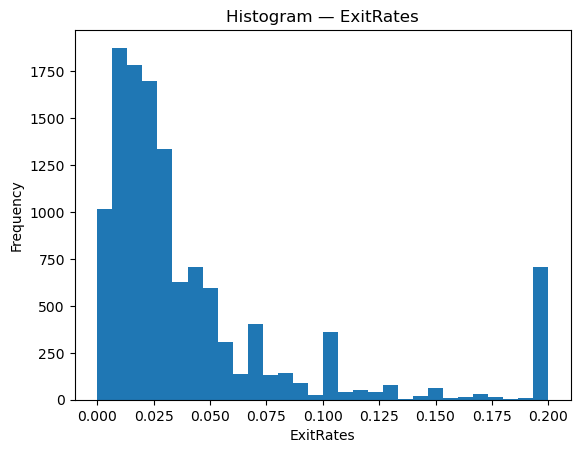

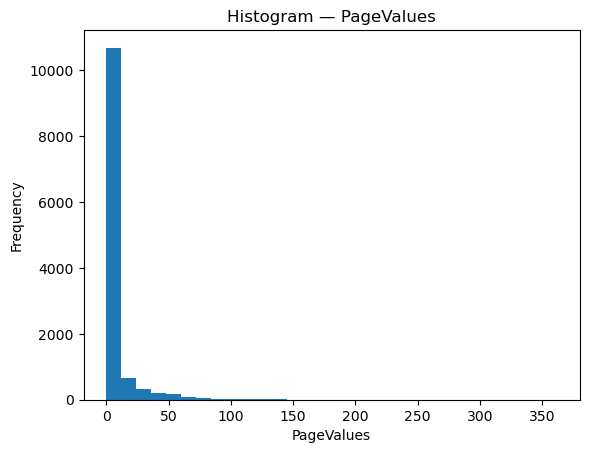

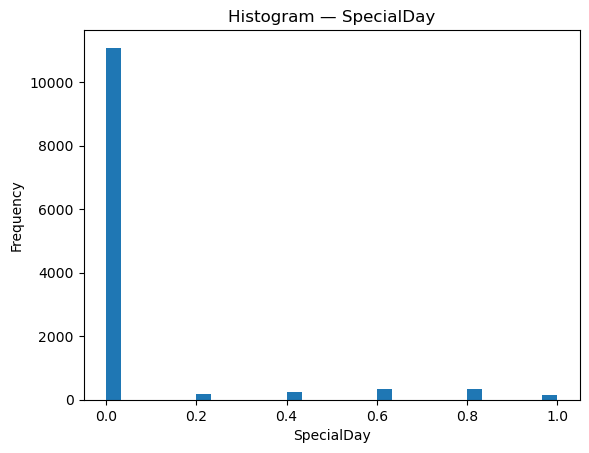


Revenue rate by PageValues quintiles:
PageValues
(-0.001, 3.06]     0.046533
(3.06, 361.764]    0.587591
Name: Revenue, dtype: float64


/var/folders/3g/39__grbn0fq4_w22vcrp4g940000gn/T/ipykernel_15588/2030707354.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rev_by_pv = df.groupby(pv_quint)["Revenue"].mean()


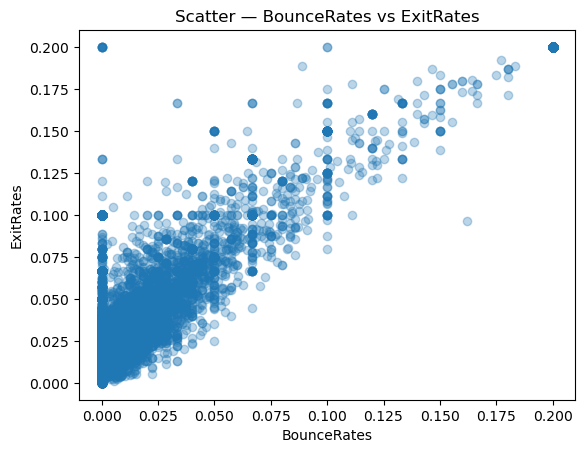

In [14]:

num_cols = ["BounceRates","ExitRates","PageValues","SpecialDay"]

for c in num_cols:
    plt.figure()
    plt.hist(df[c].dropna(), bins=30)
    plt.title(f"Histogram — {c}")
    plt.xlabel(c); plt.ylabel("Frequency")
    plt.show()

import pandas as pd
pv_quint = pd.qcut(df["PageValues"], q=5, duplicates='drop')
rev_by_pv = df.groupby(pv_quint)["Revenue"].mean()
print("\nRevenue rate by PageValues quintiles:")
print(rev_by_pv)

plt.figure()
plt.scatter(df["BounceRates"], df["ExitRates"], alpha=0.3)
plt.title("Scatter — BounceRates vs ExitRates")
plt.xlabel("BounceRates"); plt.ylabel("ExitRates")
plt.show()


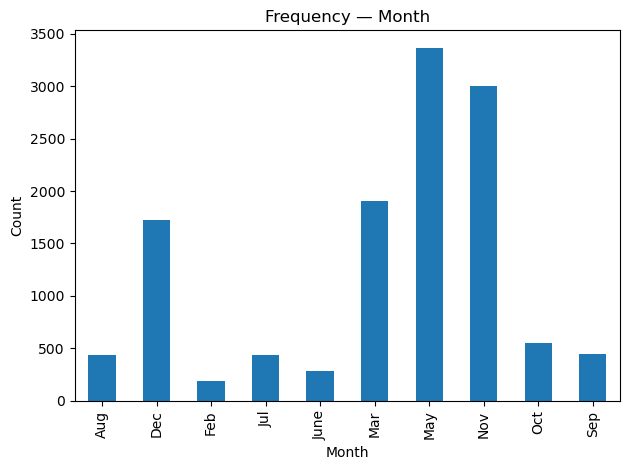

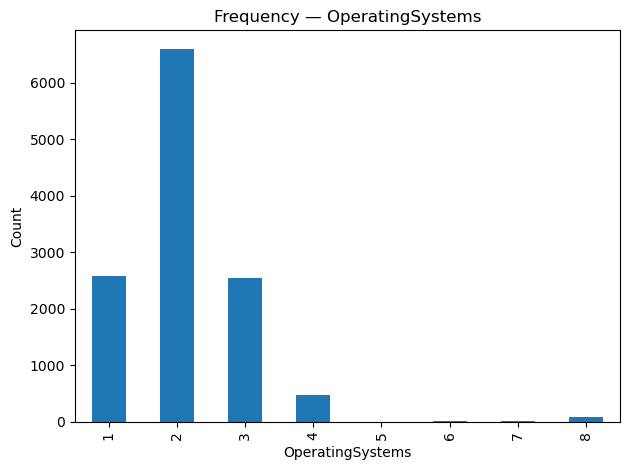

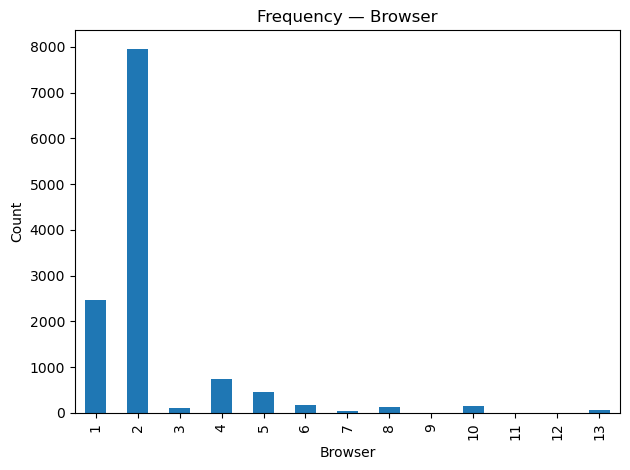

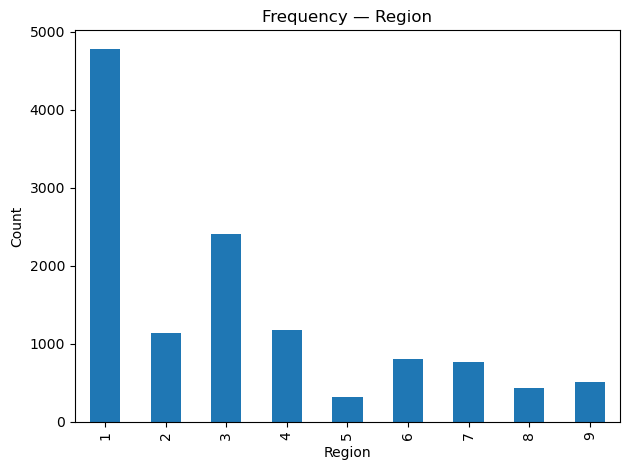

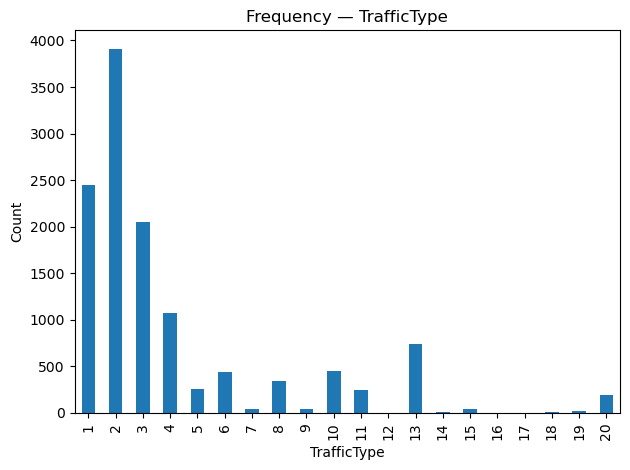

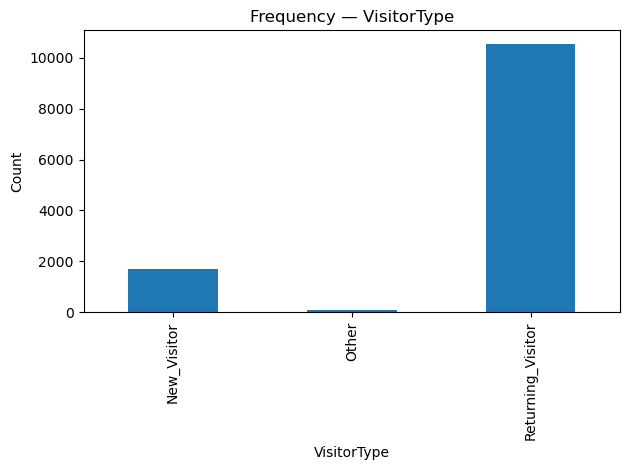


Revenue rate by Month:
Month
Aug     0.175520
Dec     0.125072
Feb     0.016304
Jul     0.152778
June    0.100694
Mar     0.100682
May     0.108502
Nov     0.253502
Oct     0.209472
Sep     0.191964
Name: Revenue, dtype: float64

Revenue rate by OperatingSystems:
OperatingSystems
1    0.146615
2    0.174973
3    0.104892
4    0.177824
5    0.166667
6    0.105263
7    0.142857
8    0.215190
Name: Revenue, dtype: float64

Revenue rate by Browser:
Browser
1     0.148253
2     0.153624
3     0.047619
4     0.176630
5     0.184154
6     0.114943
7     0.122449
8     0.155556
9     0.000000
10    0.196319
11    0.166667
12    0.300000
13    0.262295
Name: Revenue, dtype: float64

Revenue rate by Region:
Region
1    0.161297
2    0.165493
3    0.145235
4    0.148054
5    0.163522
6    0.139130
7    0.156373
8    0.129032
9    0.168297
Name: Revenue, dtype: float64

Revenue rate by TrafficType:
TrafficType
1     0.106895
2     0.216458
3     0.087719
4     0.154350
5     0.215385
6     0.1193

/var/folders/3g/39__grbn0fq4_w22vcrp4g940000gn/T/ipykernel_15588/871662227.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(c)["Revenue"].mean().sort_index())


In [15]:

cat_cols = ["Month","OperatingSystems","Browser","Region","TrafficType","VisitorType"]

for c in cat_cols:
    counts = df[c].value_counts().sort_index()
    plt.figure()
    counts.plot(kind="bar")
    plt.title(f"Frequency — {c}")
    plt.xlabel(c); plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

for c in cat_cols:
    print(f"\nRevenue rate by {c}:")
    print(df.groupby(c)["Revenue"].mean().sort_index())


In [16]:

print("Average counts by Weekend:")
print(df.groupby("Weekend")[["Administrative","Informational","ProductRelated"]].mean())

print("\nAverage counts by VisitorType:")
print(df.groupby("VisitorType")[["Administrative","Informational","ProductRelated"]].mean())

print("\nAverage counts by SpecialDay > 0:")
print(df.groupby(df["SpecialDay"] > 0)[["Administrative","Informational","ProductRelated"]].mean())


Average counts by Weekend:
         Administrative  Informational  ProductRelated
Weekend                                               
False          2.266857       0.478546       31.337455
True           2.474547       0.586123       33.031381

Average counts by VisitorType:
                   Administrative  Informational  ProductRelated
VisitorType                                                     
New_Visitor              2.551948       0.333530       18.054900
Other                    1.470588       0.176471       12.470588
Returning_Visitor        2.283954       0.533504       34.082457

Average counts by SpecialDay > 0:
            Administrative  Informational  ProductRelated
SpecialDay                                               
False             2.425670       0.524867       32.223486
True              1.336531       0.314948       27.374101


/var/folders/3g/39__grbn0fq4_w22vcrp4g940000gn/T/ipykernel_15588/4025643589.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("VisitorType")[["Administrative","Informational","ProductRelated"]].mean())


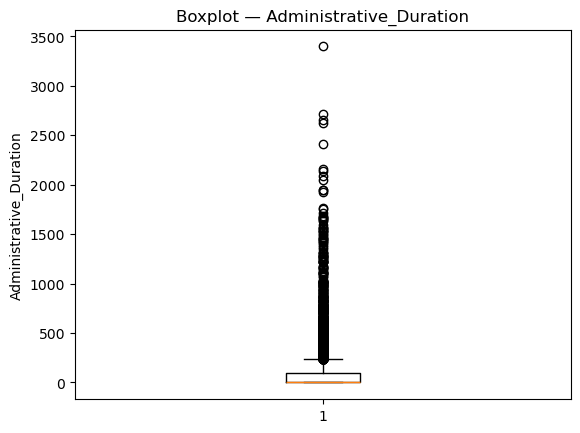

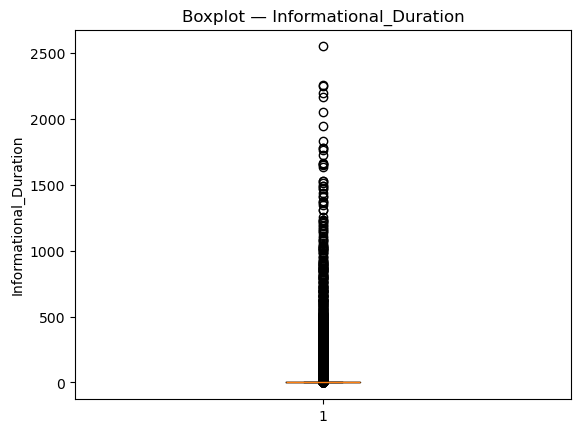

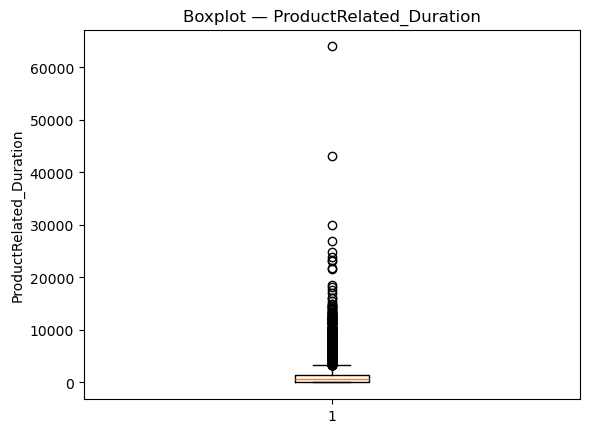

In [17]:

dur_cols = ["Administrative_Duration","Informational_Duration","ProductRelated_Duration"]

for c in dur_cols:
    plt.figure()
    plt.boxplot(df[c].dropna(), vert=True)
    plt.title(f"Boxplot — {c}")
    plt.ylabel(c)
    plt.show()


In [18]:
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
